# **E-commerce Business Intelligence EDA**

**Step 1 : Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

**Step 2 : Upload & Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sales_dataset.csv to sales_dataset.csv


In [4]:
df = pd.read_csv('sales_dataset.csv')

/tmp/ipython-input-2144452552.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('sales_dataset.csv')


In [5]:
# check data:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

,Qty,Amount,ship-postal-code
count,128949.000000,121155.000000,128916.000000
mean,0.904629,648.550806,463978.298008
std,0.314782,281.218324,191473.322953
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


**STEP 3 : Data Understanding (Exploration)**

In [6]:
# check shape
df.shape

(128949, 23)

In [7]:
# Check missing values
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [8]:
#  Check duplicate records
df.duplicated().sum()

np.int64(6)

**STEP 4: Data Cleaning**

In [9]:
# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipython-input-1748690327.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [10]:
#  Handle Missing Values in Amount (Replace with Median)
df['Amount'].fillna(df['Amount'].median(), inplace=True)

/tmp/ipython-input-1683715884.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(df['Amount'].median(), inplace=True)


In [11]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [12]:
# Standardize Column Names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# **Task 1 : Financial Performance Analysis**

In [13]:
# Total Revenue

total_revenue = df['amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 83286092.94


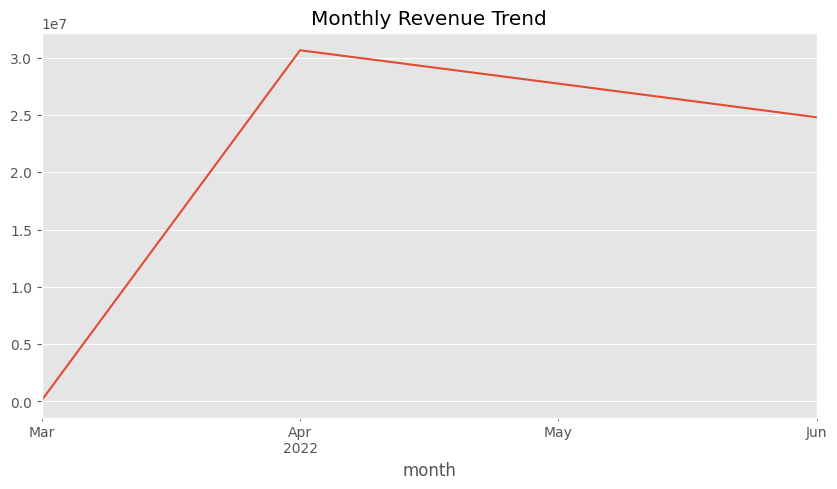

In [14]:
# Revenue Over Time (Monthly Trend)

df['month'] = df['date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['amount'].sum()

monthly_revenue.plot(kind='line', figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()


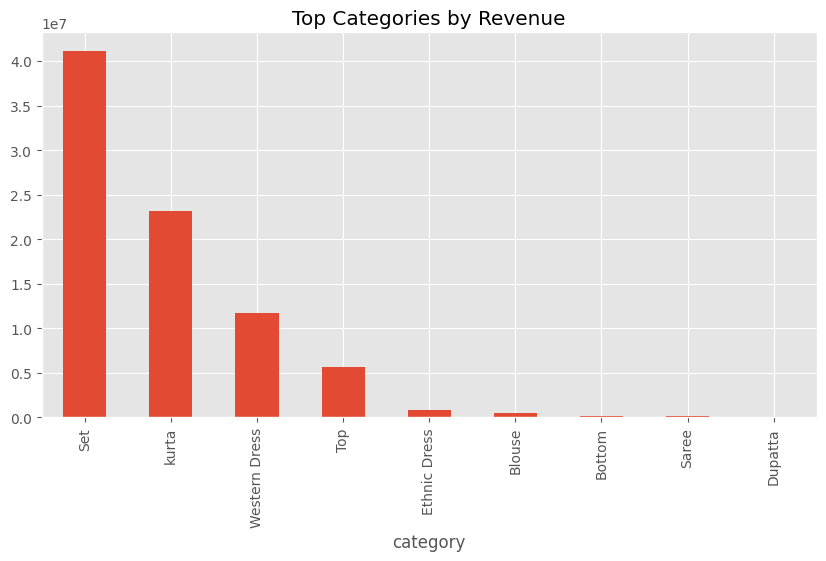

In [15]:
#  Best Selling Products (Category)

top_categories = df.groupby('category')['amount'].sum().sort_values(ascending=False)

top_categories.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Categories by Revenue")
plt.show()

In [16]:
# Average Order Value (AOV)

aov = df.groupby('order_id')['amount'].sum().mean()
print("Average Order Value:", aov)

Average Order Value: 692.020846683063


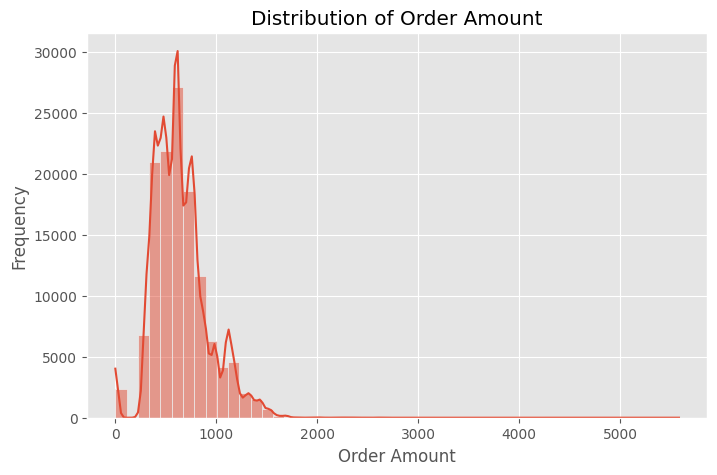

In [17]:
# Revenue Distribution (Histogram)
# See how order amounts are distributed

plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount")
plt.ylabel("Frequency")
plt.show()

/tmp/ipython-input-1812215197.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='date')['amount'].sum()


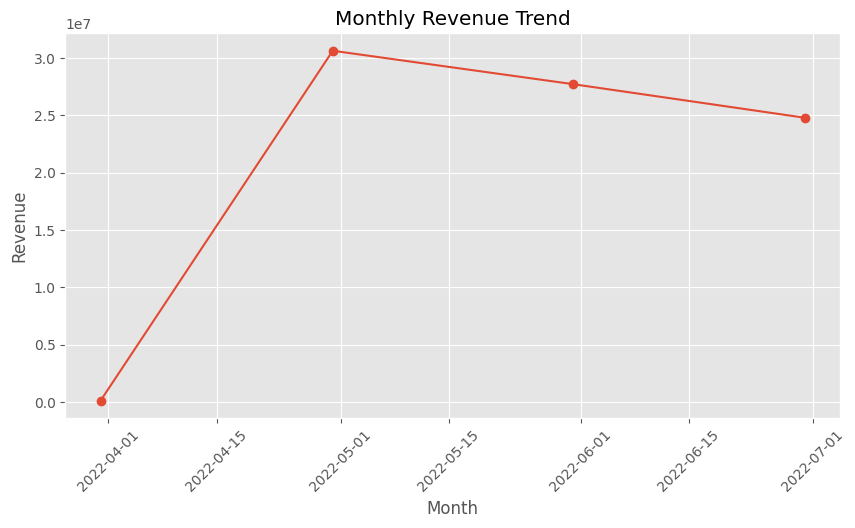

In [18]:
# Monthly Revenue Trend (Line + Markers)

monthly_revenue = df.resample('M', on='date')['amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

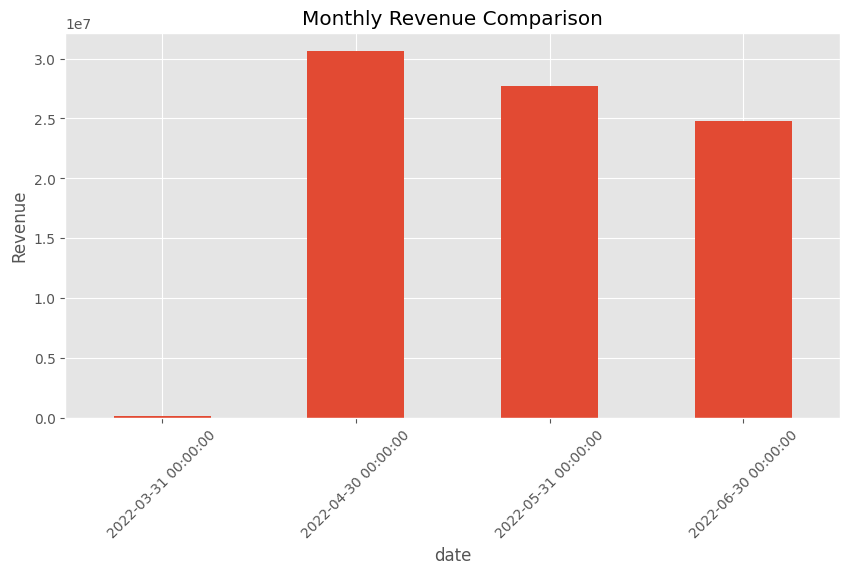

In [19]:
# Monthly Revenue Bar Chart

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='bar')
plt.title("Monthly Revenue Comparison")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

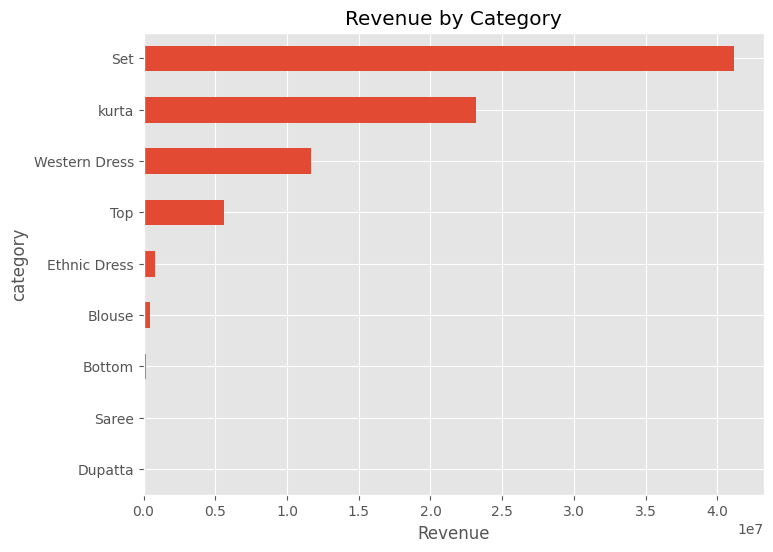

In [20]:
# Revenue by Category (Horizontal Bar – Better Visual)

category_revenue = df.groupby('category')['amount'].sum().sort_values()

plt.figure(figsize=(8,6))
category_revenue.plot(kind='barh')
plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.show()

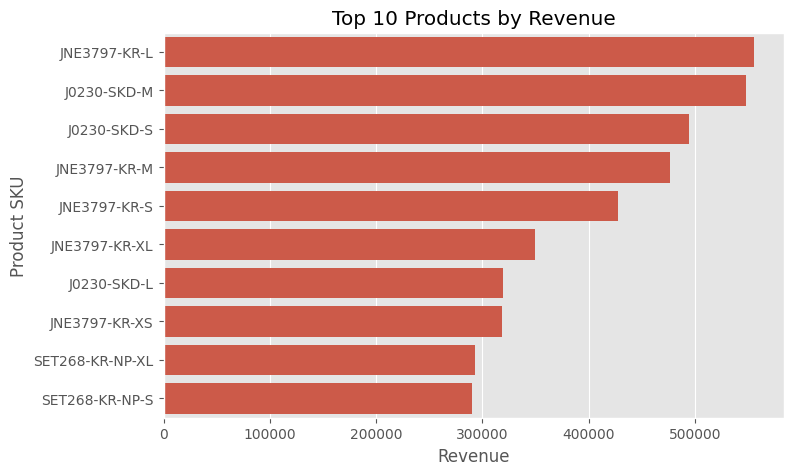

In [21]:
# Top 10 Products by Revenue

top_products = df.groupby('sku')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product SKU")
plt.show()

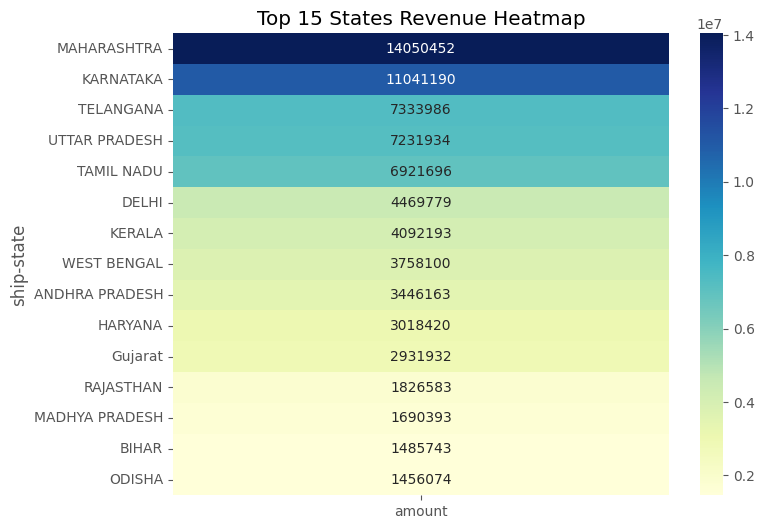

In [22]:
# Revenue by State (Heatmap Style)

state_revenue = df.groupby('ship-state')['amount'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.heatmap(state_revenue.to_frame(), annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Top 15 States Revenue Heatmap")
plt.show()

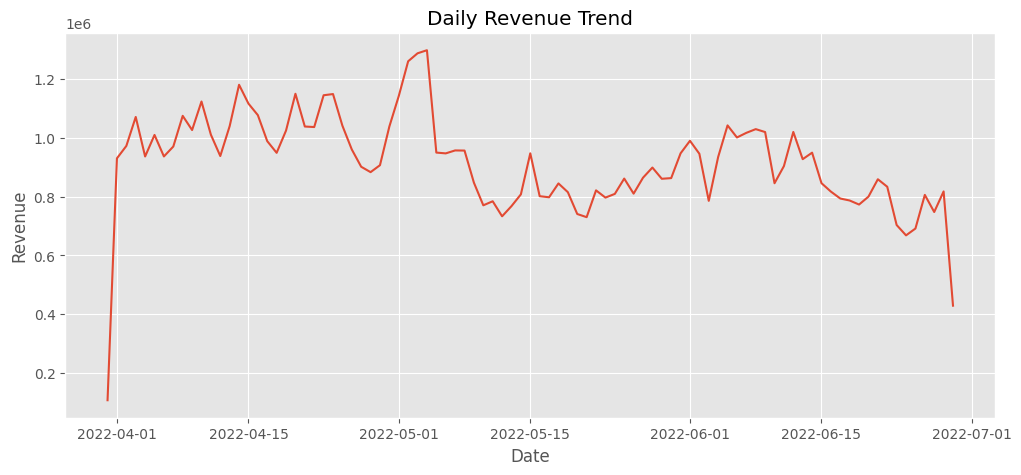

In [23]:
# Daily Revenue Trend (For Detailed Analysis)

daily_revenue = df.resample('D', on='date')['amount'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

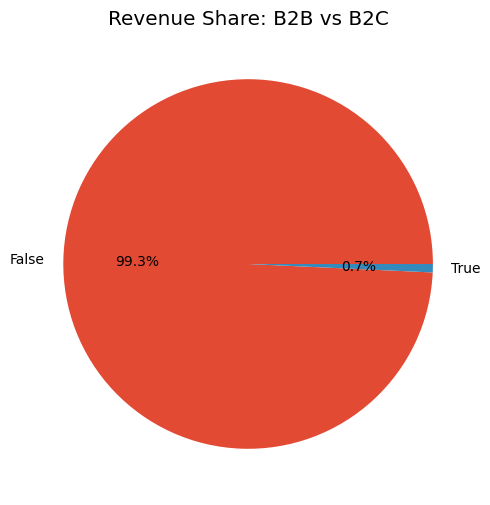

In [24]:
# Revenue by B2B vs B2C (Pie Chart)

b2b_revenue = df.groupby('b2b')['amount'].sum()

plt.figure(figsize=(6,6))
plt.pie(b2b_revenue, labels=b2b_revenue.index, autopct='%1.1f%%')
plt.title("Revenue Share: B2B vs B2C")
plt.show()

# **Task 2 : Customer Insights Analysis**

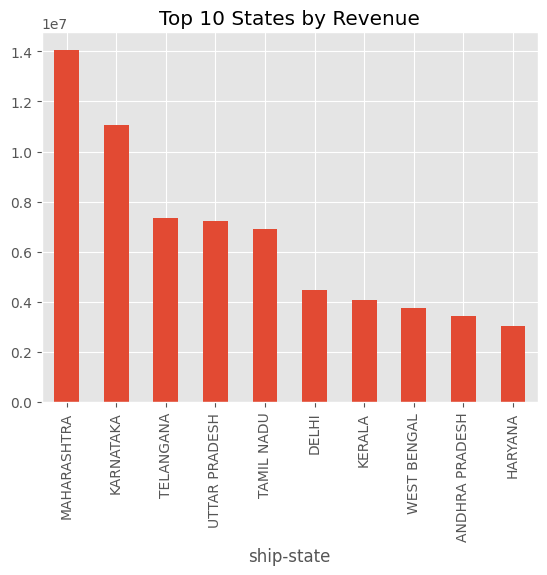

In [25]:
# Top Performing States

top_states = df.groupby('ship-state')['amount'].sum().sort_values(ascending=False)

top_states.head(10).plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.show()

In [26]:
#  Cancellation Rate

cancellation_rate = df[df['status']=="Cancelled"].shape[0] / df.shape[0]
print("Cancellation Rate:", cancellation_rate)

Cancellation Rate: 0.142217879217949


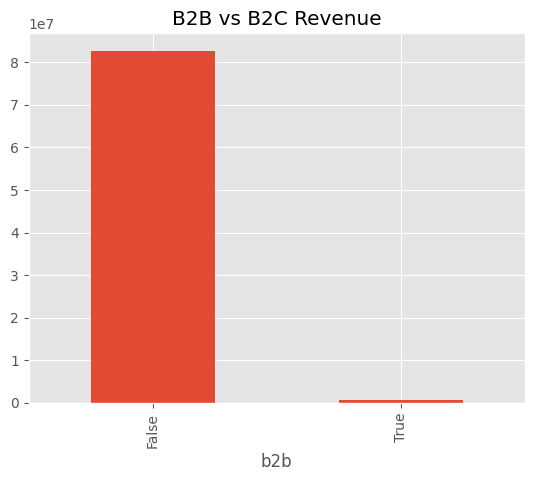

In [27]:
# B2B vs B2C Revenue

df.groupby('b2b')['amount'].sum().plot(kind='bar')
plt.title("B2B vs B2C Revenue")
plt.show()

/tmp/ipython-input-3792125504.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette="Blues_r")


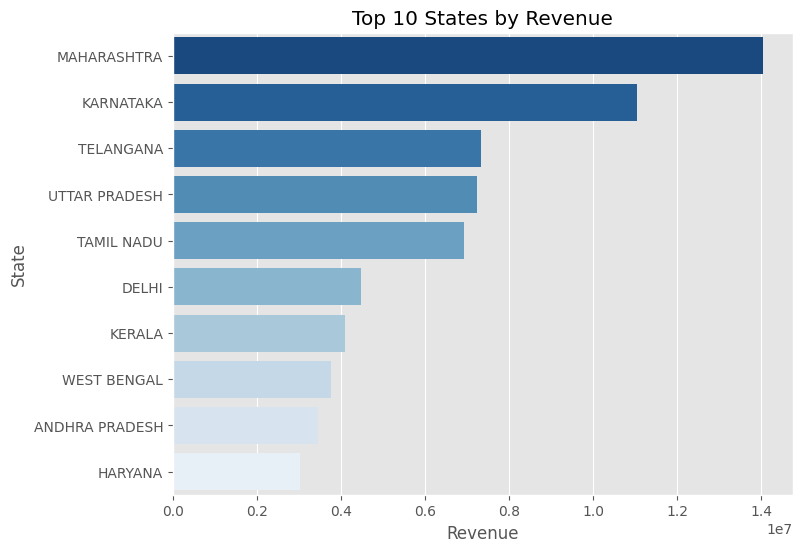

In [28]:
# Top 10 States by Revenue

top_states = df.groupby('ship-state')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_states.values, y=top_states.index, palette="Blues_r")
plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")
plt.show()

/tmp/ipython-input-3239664649.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="Greens_r")


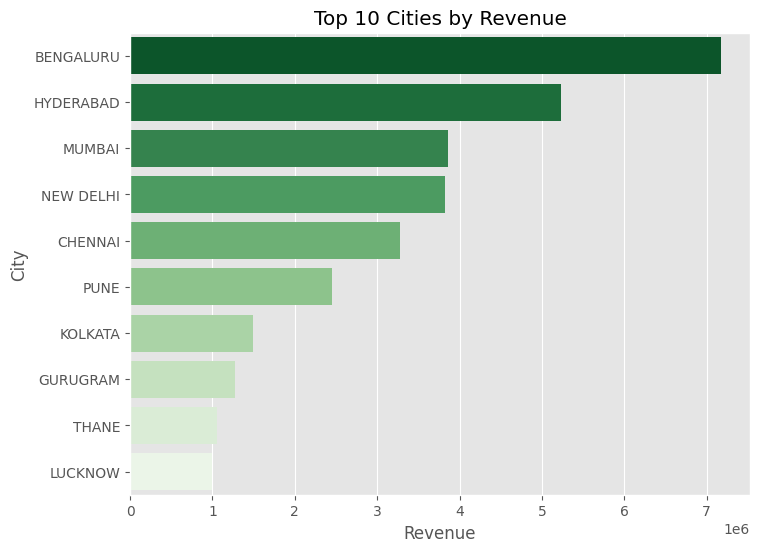

In [29]:
# Revenue by City

top_cities = df.groupby('ship-city')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Greens_r")
plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.show()

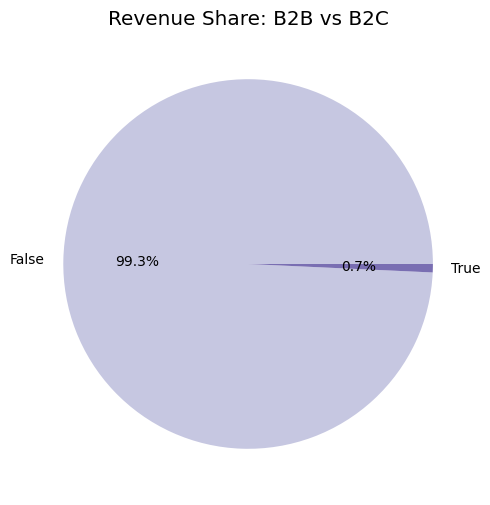

In [30]:
# Customer Type: B2B vs B2C

b2b_revenue = df.groupby('b2b')['amount'].sum()

plt.figure(figsize=(6,6))
colors = sns.color_palette("Purples", len(b2b_revenue))
plt.pie(b2b_revenue, labels=b2b_revenue.index, autopct='%1.1f%%', colors=colors)
plt.title("Revenue Share: B2B vs B2C")
plt.show()


/tmp/ipython-input-1761550564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="crest")


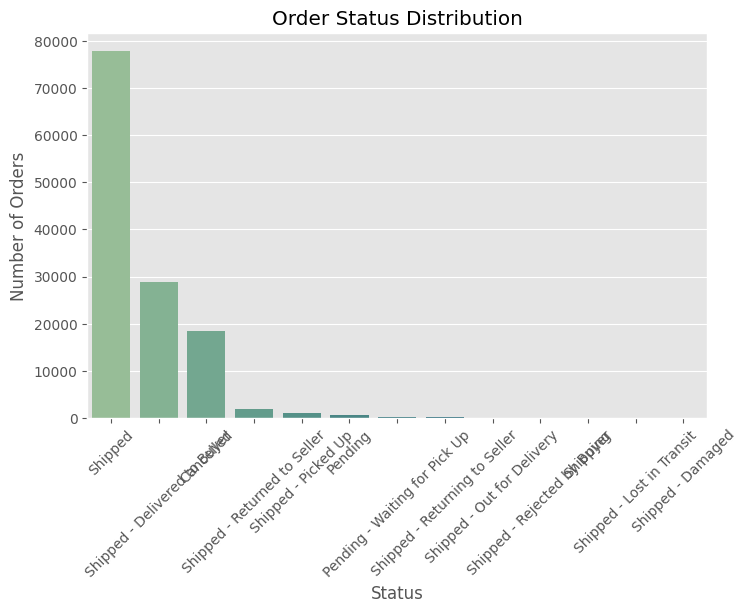

In [31]:
# Order Status Distribution

status_counts = df['status'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="crest")
plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


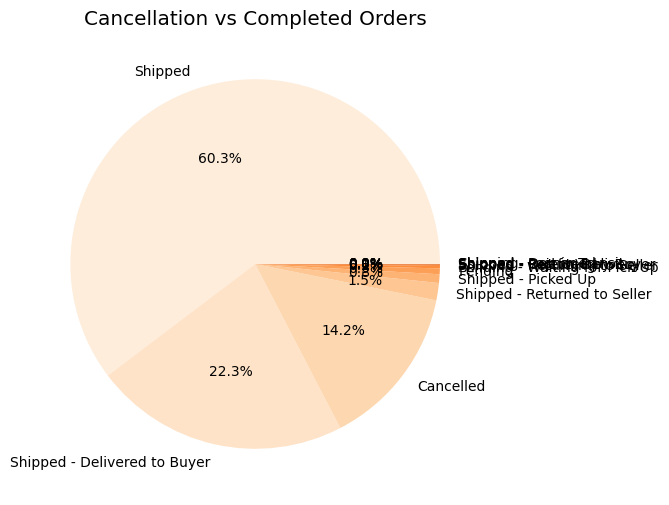

In [32]:
#  Cancellation Rate Visualization

cancel_data = df['status'].value_counts()

plt.figure(figsize=(6,6))
colors = sns.color_palette("Oranges", len(cancel_data))
plt.pie(cancel_data, labels=cancel_data.index, autopct='%1.1f%%', colors=colors)
plt.title("Cancellation vs Completed Orders")
plt.show()

/tmp/ipython-input-3584678737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_aov.values, y=state_aov.index, palette="viridis")


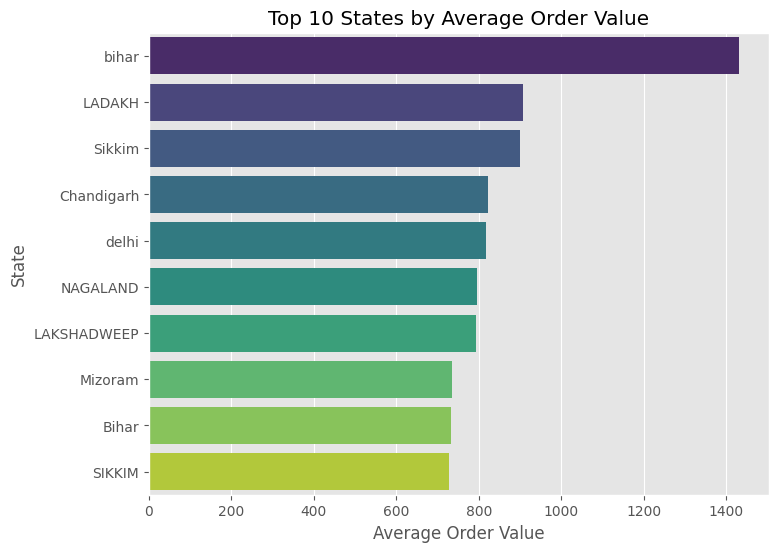

In [33]:
# Average Order Value by State

state_aov = df.groupby('ship-state')['amount'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=state_aov.values, y=state_aov.index, palette="viridis")
plt.title("Top 10 States by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("State")
plt.show()

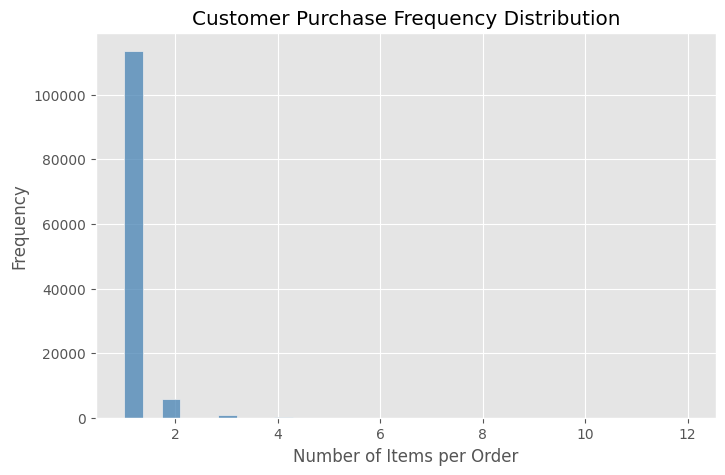

In [34]:
# Customer Purchase Frequency

orders_per_customer = df.groupby('order_id')['amount'].count()

plt.figure(figsize=(8,5))
sns.histplot(orders_per_customer, bins=30, color="steelblue")
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Items per Order")
plt.ylabel("Frequency")
plt.show()

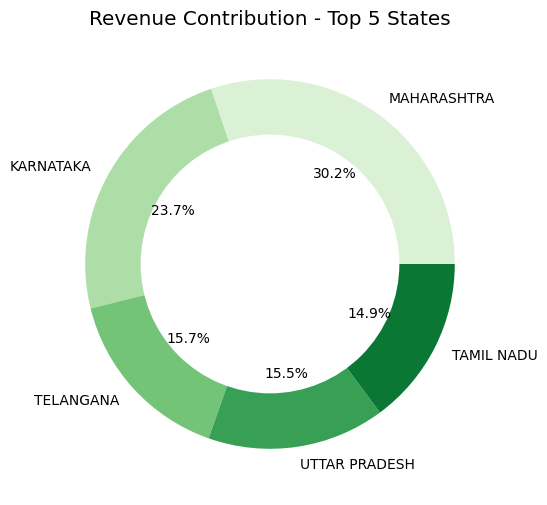

In [35]:
# Revenue Contribution by Top 5 States

top5_states = df.groupby('ship-state')['amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(6,6))
colors = sns.color_palette("Greens", len(top5_states))
plt.pie(top5_states, labels=top5_states.index, autopct='%1.1f%%', colors=colors)
plt.title("Revenue Contribution - Top 5 States")

# Donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.show()

# **Task 3 : Logistics & Fulfillment Analysis**

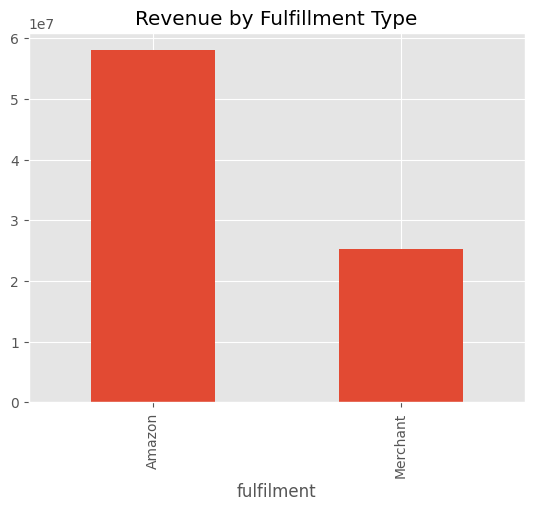

In [38]:
# Fulfillment Comparison

df.groupby('fulfilment')['amount'].sum().plot(kind='bar')
plt.title("Revenue by Fulfillment Type")
plt.show()

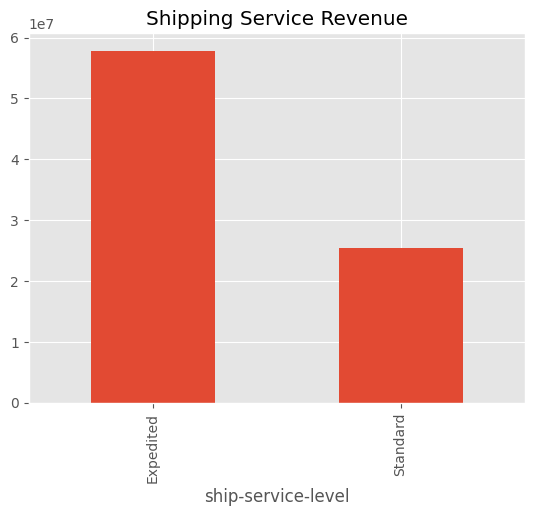

In [39]:
# Shipping Service Level Analysis

df.groupby('ship-service-level')['amount'].sum().plot(kind='bar')
plt.title("Shipping Service Revenue")
plt.show()

/tmp/ipython-input-2192881448.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fulfillment_revenue.index,


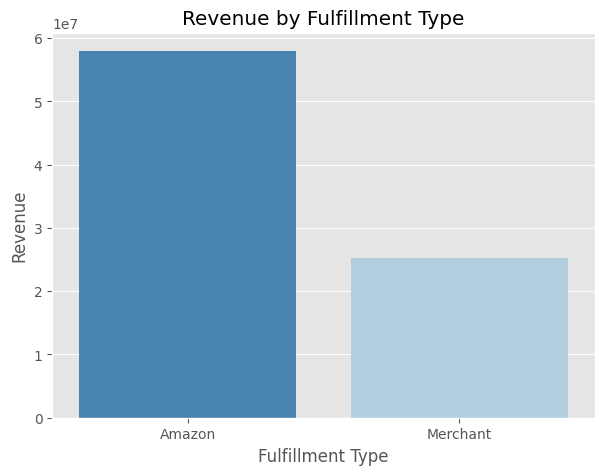

In [41]:
#  Revenue by Fulfillment Type

fulfillment_revenue = df.groupby('fulfilment')['amount'].sum()

plt.figure(figsize=(7,5))
sns.barplot(x=fulfillment_revenue.index,
            y=fulfillment_revenue.values,
            palette="Blues_r")

plt.title("Revenue by Fulfillment Type")
plt.xlabel("Fulfillment Type")
plt.ylabel("Revenue")
plt.show()


/tmp/ipython-input-205649661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fulfillment_orders.index,


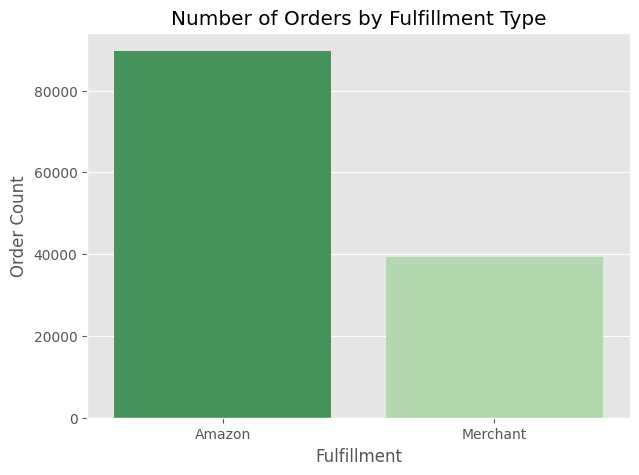

In [43]:
# Order Count by Fulfillment

fulfillment_orders = df['fulfilment'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=fulfillment_orders.index,
            y=fulfillment_orders.values,
            palette="Greens_r")

plt.title("Number of Orders by Fulfillment Type")
plt.xlabel("Fulfillment")
plt.ylabel("Order Count")
plt.show()

/tmp/ipython-input-3982611498.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=service_counts.index,


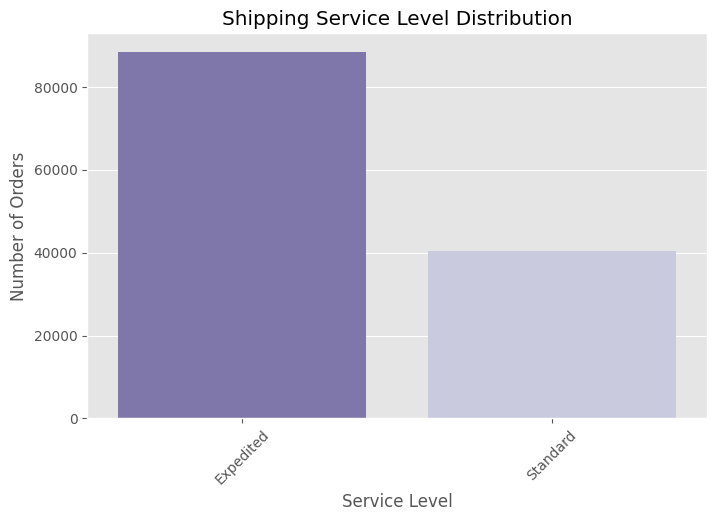

In [44]:
# Shipping Service Level Distribution

service_counts = df['ship-service-level'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=service_counts.index,
            y=service_counts.values,
            palette="Purples_r")

plt.title("Shipping Service Level Distribution")
plt.xlabel("Service Level")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1196368694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=service_revenue.index,


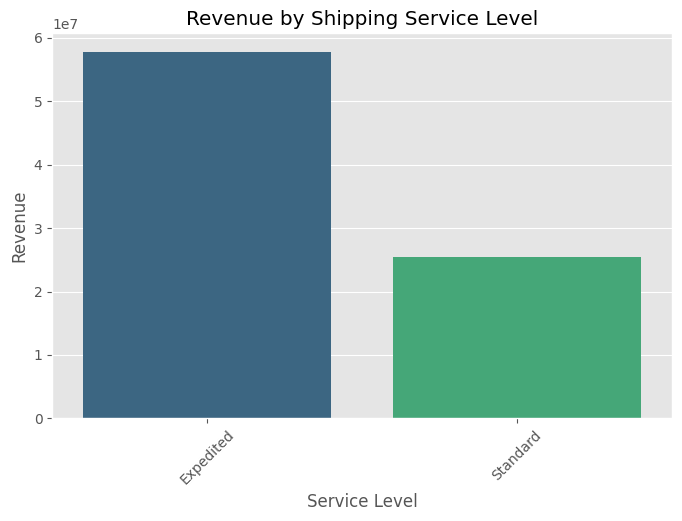

In [45]:
# Revenue by Shipping Service Level

service_revenue = df.groupby('ship-service-level')['amount'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=service_revenue.index,
            y=service_revenue.values,
            palette="viridis")

plt.title("Revenue by Shipping Service Level")
plt.xlabel("Service Level")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

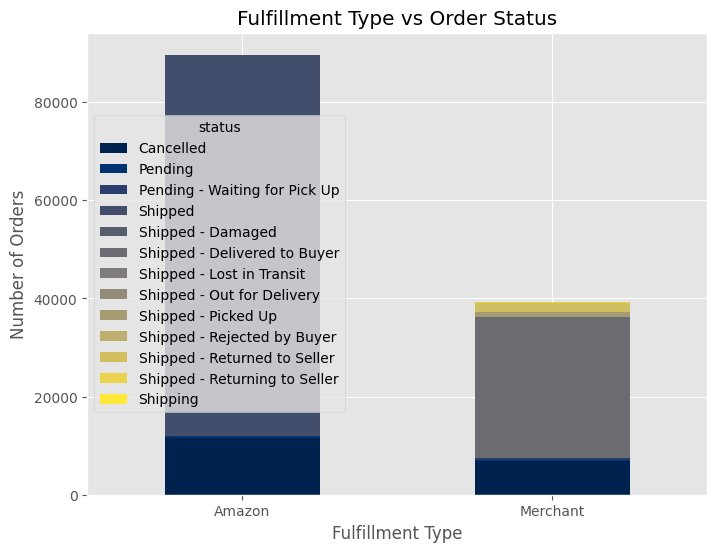

In [47]:
# Fulfillment vs Order Status

status_fulfillment = pd.crosstab(df['fulfilment'], df['status'])

status_fulfillment.plot(kind='bar',
                        stacked=True,
                        colormap='cividis',
                        figsize=(8,6))

plt.title("Fulfillment Type vs Order Status")
plt.xlabel("Fulfillment Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

/tmp/ipython-input-2779126781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aov_fulfillment.index,


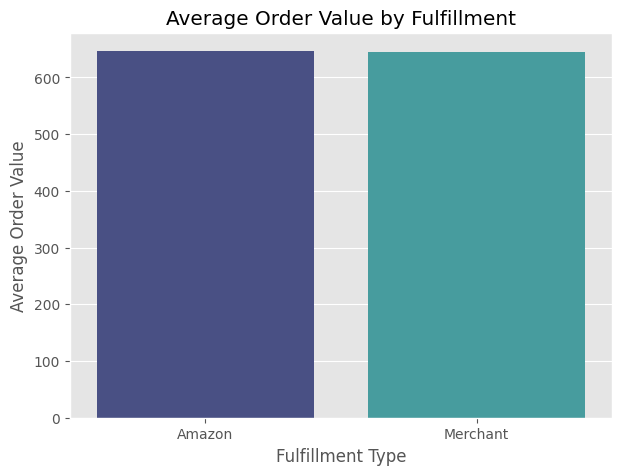

In [49]:
# Average Order Value by Fulfillment

aov_fulfillment = df.groupby('fulfilment')['amount'].mean()

plt.figure(figsize=(7,5))
sns.barplot(x=aov_fulfillment.index,
            y=aov_fulfillment.values,
            palette="mako")

plt.title("Average Order Value by Fulfillment")
plt.xlabel("Fulfillment Type")
plt.ylabel("Average Order Value")
plt.show()

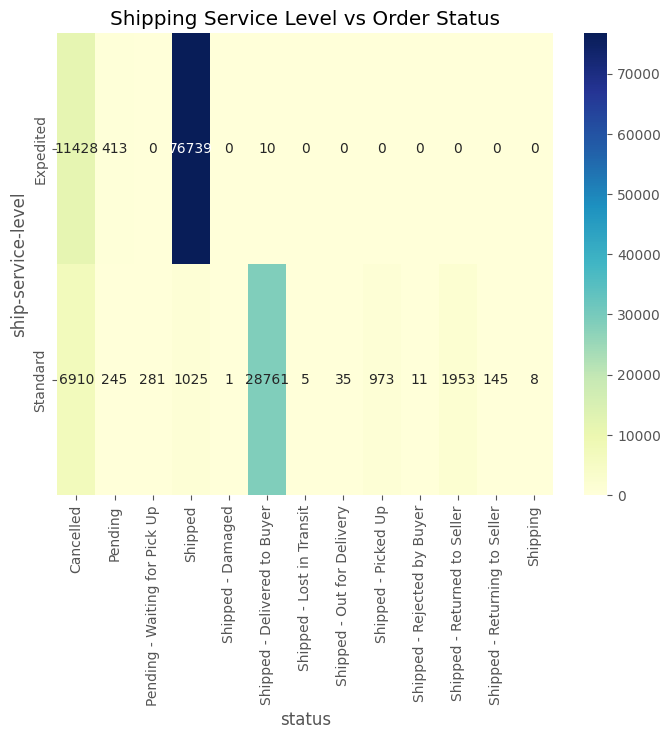

In [50]:
# Delivery Performance Heatmap

heat_data = pd.crosstab(df['ship-service-level'], df['status'])

plt.figure(figsize=(8,6))
sns.heatmap(heat_data,
            annot=True,
            fmt='d',
            cmap="YlGnBu")

plt.title("Shipping Service Level vs Order Status")
plt.show()

# **Task 4 : Product Management & Inventory**

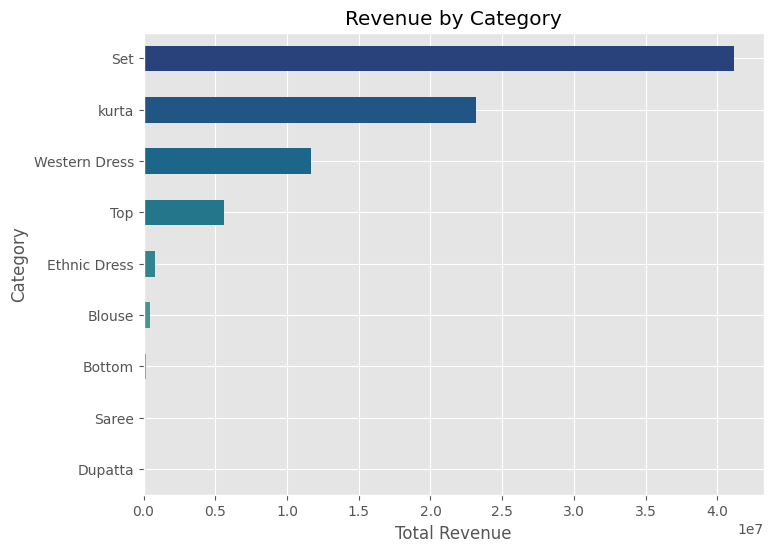

In [55]:
# Revenue by Category

category_revenue = df.groupby('category')['amount'].sum().sort_values()

plt.figure(figsize=(8,6))
category_revenue.plot(kind='barh', color=sns.color_palette("crest", len(category_revenue)))

plt.title("Revenue by Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.show()

/tmp/ipython-input-1338788389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skus.values,


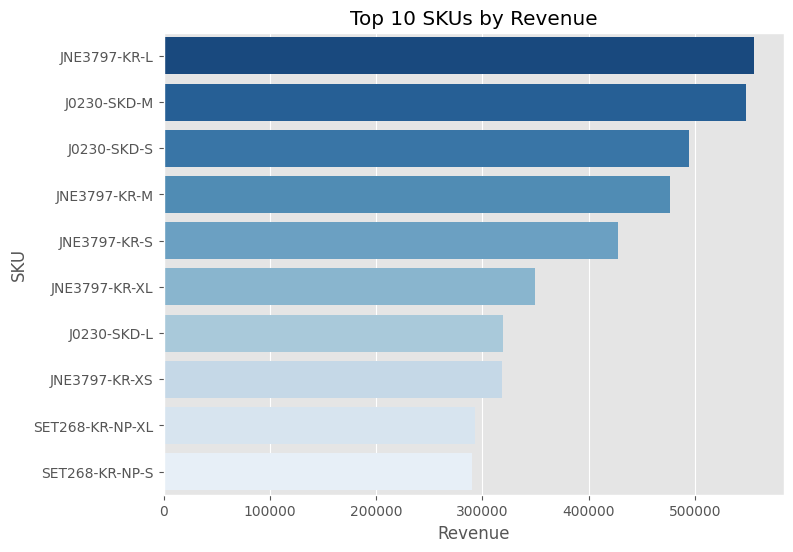

In [56]:
# Top 10 SKUs by Revenue

top_skus = df.groupby('sku')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_skus.values,
            y=top_skus.index,
            palette="Blues_r")

plt.title("Top 10 SKUs by Revenue")
plt.xlabel("Revenue")
plt.ylabel("SKU")
plt.show()

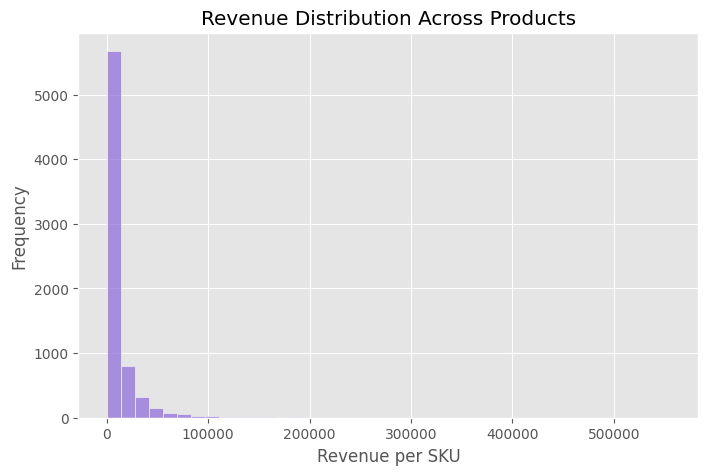

In [57]:
# Revenue Distribution Across SKUs

sku_revenue = df.groupby('sku')['amount'].sum()

plt.figure(figsize=(8,5))
sns.histplot(sku_revenue, bins=40, color="mediumpurple")

plt.title("Revenue Distribution Across Products")
plt.xlabel("Revenue per SKU")
plt.ylabel("Frequency")
plt.show()

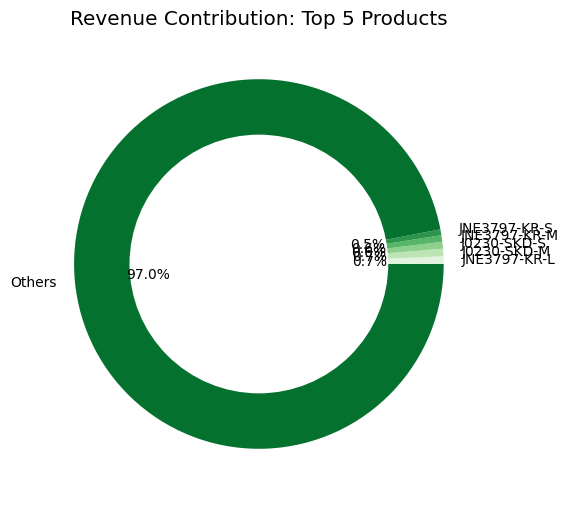

In [58]:
# Product Revenue Contribution (Top 5 vs Others – Donut Chart)

top5 = sku_revenue.sort_values(ascending=False).head(5)
others = sku_revenue.sum() - top5.sum()

values = list(top5.values) + [others]
labels = list(top5.index) + ["Others"]

plt.figure(figsize=(6,6))
colors = sns.color_palette("Greens", len(values))

plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title("Revenue Contribution: Top 5 Products")

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.show()

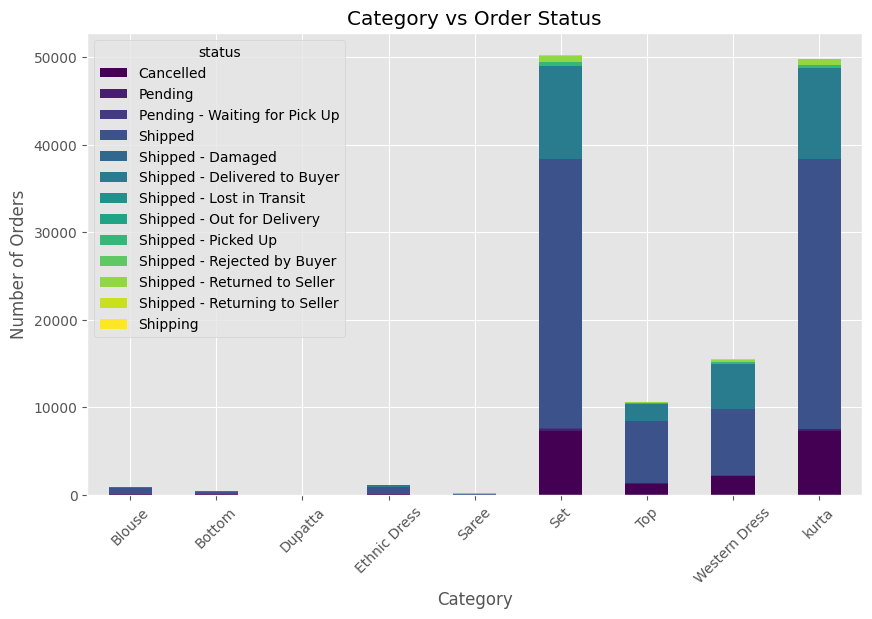

In [59]:
#  Category vs Order Status (Inventory Risk Indicator )

category_status = pd.crosstab(df['category'], df['status'])

category_status.plot(kind='bar',
                     stacked=True,
                     colormap='viridis',
                     figsize=(10,6))

plt.title("Category vs Order Status")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-4053562225.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_skus.values,


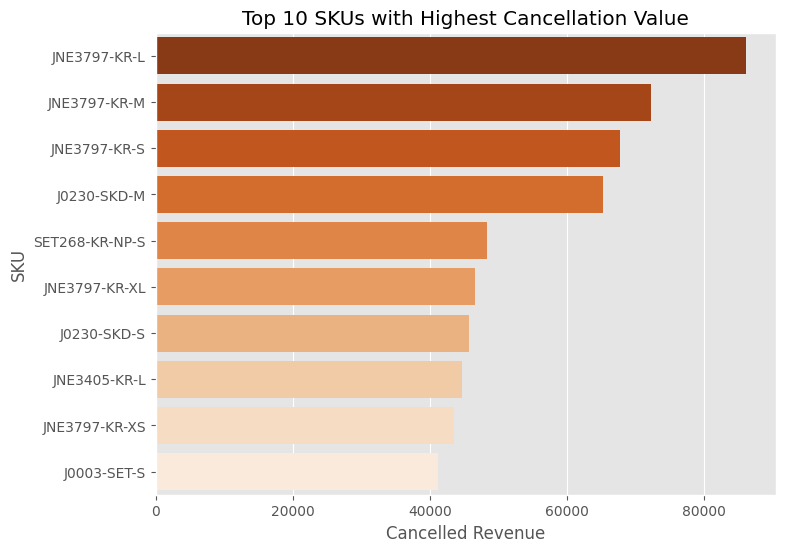

In [60]:
# High Cancellation Products

cancelled = df[df['status'] == "Cancelled"]
cancel_skus = cancelled.groupby('sku')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=cancel_skus.values,
            y=cancel_skus.index,
            palette="Oranges_r")

plt.title("Top 10 SKUs with Highest Cancellation Value")
plt.xlabel("Cancelled Revenue")
plt.ylabel("SKU")
plt.show()

/tmp/ipython-input-2570626470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sku_revenue.values,


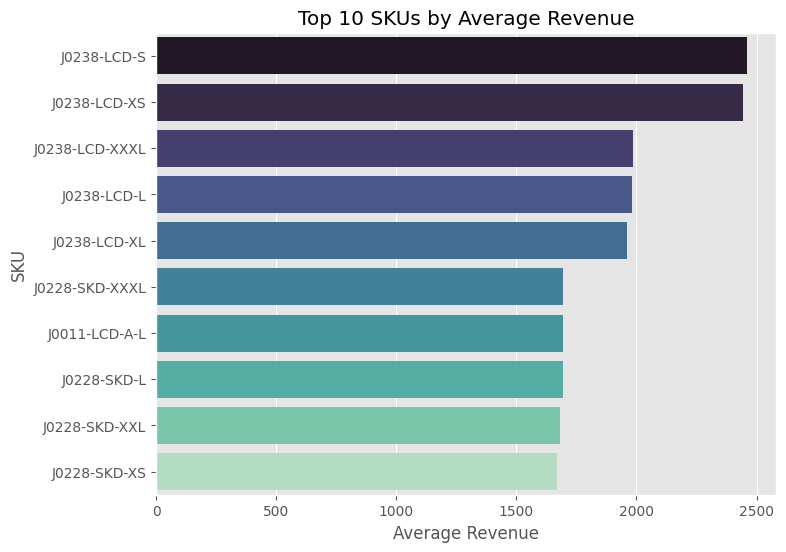

In [61]:
# Average Revenue per Product

avg_sku_revenue = df.groupby('sku')['amount'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=avg_sku_revenue.values,
            y=avg_sku_revenue.index,
            palette="mako")

plt.title("Top 10 SKUs by Average Revenue")
plt.xlabel("Average Revenue")
plt.ylabel("SKU")
plt.show()

# **Task 5 :  STEP 9: Customer Satisfaction & Returns**

In [62]:
# High Return Categories

returns = df[df['status']=="Returned"]
returns.groupby('category')['amount'].sum().sort_values(ascending=False)

,amount
category,


In [63]:
# Problematic Products
df[df['status']=="Cancelled"].groupby('sku')['amount'].sum().sort_values(ascending=False).head()

,amount
sku,
JNE3797-KR-L,86124.77
JNE3797-KR-M,72220.16
JNE3797-KR-S,67678.57
J0230-SKD-M,65263.20
SET268-KR-NP-S,48326.48


/tmp/ipython-input-805495313.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index,


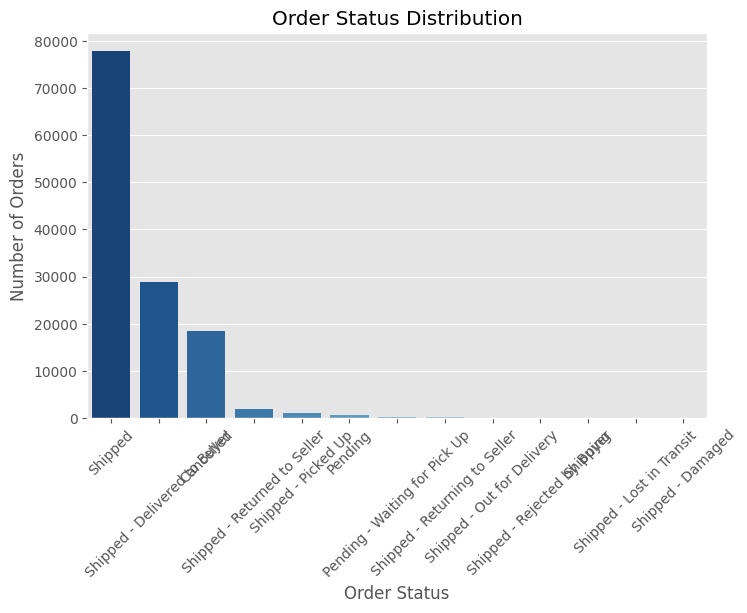

In [64]:
# Order Status Distribution

status_counts = df['status'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=status_counts.index,
            y=status_counts.values,
            palette="Blues_r")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

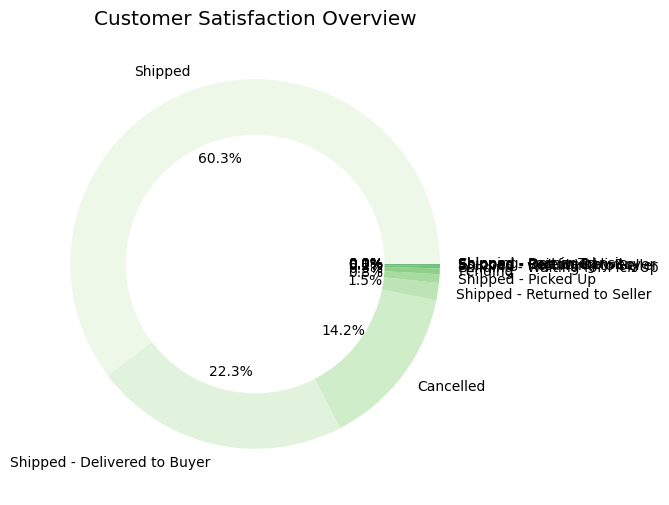

In [65]:
# Returns vs Completed Orders

return_data = df['status'].value_counts()

plt.figure(figsize=(6,6))
colors = sns.color_palette("Greens", len(return_data))

plt.pie(return_data,
        labels=return_data.index,
        autopct='%1.1f%%',
        colors=colors)

plt.title("Customer Satisfaction Overview")

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.show()

/tmp/ipython-input-3377951762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_by_category.values,


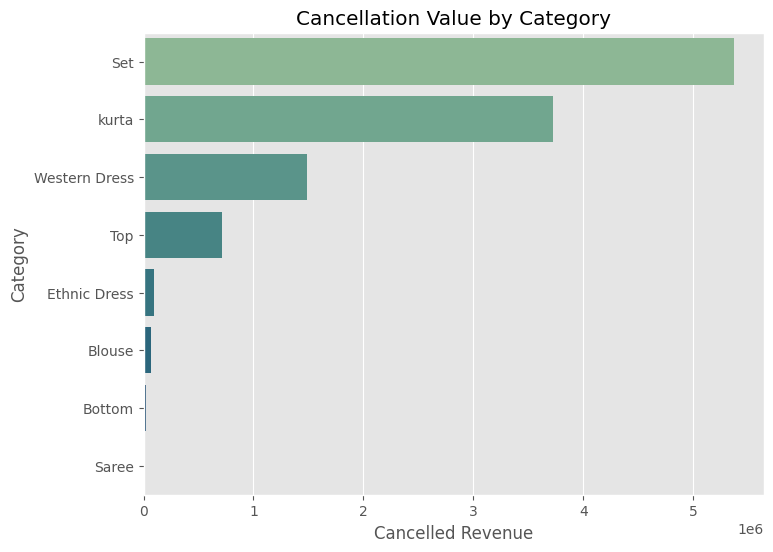

In [67]:
# Cancellation Rate by Category

cancelled = df[df['status'] == "Cancelled"]
cancel_by_category = cancelled.groupby('category')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=cancel_by_category.values,
            y=cancel_by_category.index,
            palette="crest")

plt.title("Cancellation Value by Category")
plt.xlabel("Cancelled Revenue")
plt.ylabel("Category")
plt.show()

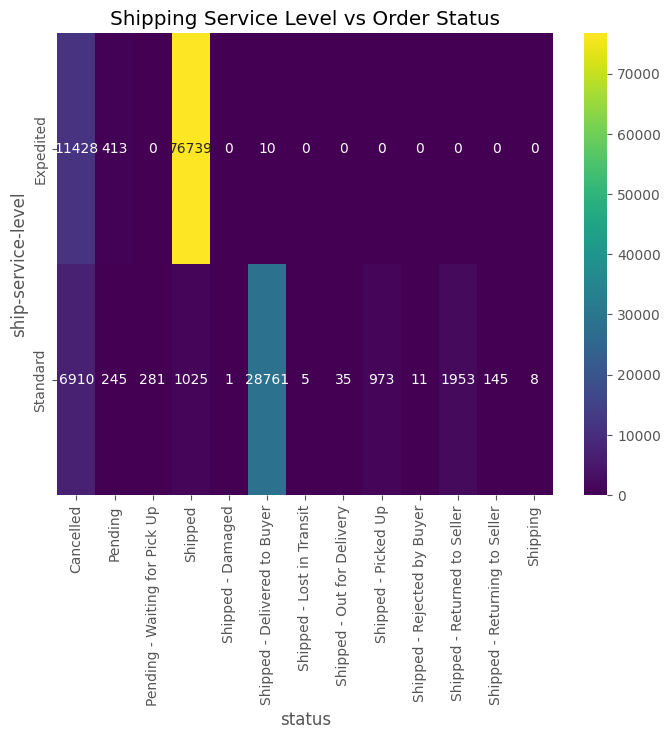

In [68]:
# Shipping Service Level vs Returns

service_status = pd.crosstab(df['ship-service-level'], df['status'])

plt.figure(figsize=(8,6))
sns.heatmap(service_status,
            annot=True,
            fmt='d',
            cmap="viridis")

plt.title("Shipping Service Level vs Order Status")
plt.show()

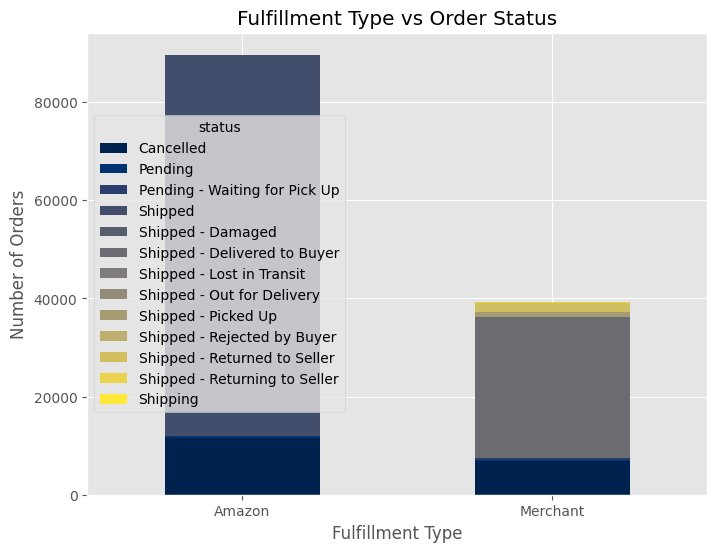

In [70]:
#  Fulfillment Type vs Returns

fulfillment_status = pd.crosstab(df['fulfilment'], df['status'])

fulfillment_status.plot(kind='bar',
                        stacked=True,
                        colormap='cividis',
                        figsize=(8,6))

plt.title("Fulfillment Type vs Order Status")
plt.xlabel("Fulfillment Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

 ## Recommendations

1. Improve inventory for high-demand categories.

2. Investigate high cancellation SKUs.

3. Offer targeted marketing in top-performing states.

4. Improve shipping speed in high-return areas.

5. Create loyalty programs for repeat customers.

6. Optimize fulfillment strategy based on performance.  
